# Step 3 — Model Inference & Evaluation

**Research question:** Can any existing pretrained PhaseNet weight serve as a
competent *global* phase picker across local, regional, and teleseismic distances?

**Approach:** Run all PhaseNet pretrained weights through `benchmark_waveforms.hdf5`
and evaluate on three tasks following Münchmeyer et al. (2022):

| Task | Metric | Description |
|------|--------|-------------|
| 1 — Detection | Recall @ threshold | Does the model find the phase? |
| 2 — Phase ID | MCC | Does it label P vs S correctly? |
| 3 — Onset time | MAE, RMSE, % outliers | How accurate is the pick time? |

**In-domain vs cross-domain:** Every result is reported both ways.
The `trained_models` column in the manifest identifies which dataset each trace
belongs to — when evaluating `PhaseNet/stead`, STEAD traces are excluded from
the cross-domain split. The MLAAPDE teleseismic traces are 100% cross-domain
for every model (none was trained on MLAAPDE).

```
benchmark_waveforms.hdf5
        │
        ▼
 3.1  Setup & model inventory
        │
        ▼
 3.2  Inference loop
        │   For each PhaseNet weight:
        │     load model → batch inference → extract P/S peaks → save
        ▼
 3.3  Metric computation
        │   Detection recall · Phase ID MCC · Onset MAE/RMSE
        │   Broken down by: model · dataset · distance bin · physics bin
        ▼
 3.4  Cross-domain analysis
        │   In-domain vs cross-domain performance matrices
        ▼
 3.5  Visualisation
        │   Heatmaps · residual distributions · SNR curves · distance breakdown
        ▼
     step3_results.parquet  +  step3_metrics.csv
```


## 3.1  Imports & Configuration


In [1]:
import numpy as np
import pandas as pd
import h5py, warnings
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict
import scipy.signal
import torch
import seisbench.models as sbm

warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ──────────────────────────────────────────────────────────────────
HDF5_PATH    = Path("benchmark_waveforms.hdf5")
INDEX_PATH   = Path("benchmark_waveforms_index.csv")
RESULTS_PATH = Path("step3_results.parquet")
METRICS_PATH = Path("step3_metrics.csv")

assert HDF5_PATH.exists(),  "benchmark_waveforms.hdf5 not found — run Step 2 first"
assert INDEX_PATH.exists(), "benchmark_waveforms_index.csv not found — run Step 2 first"

# ── Inference parameters ───────────────────────────────────────────────────
BATCH_SIZE      = 64       # traces per GPU/CPU batch
TARGET_SR       = 100      # Hz
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD_P     = 0.3      # probability threshold for P detection
THRESHOLD_S     = 0.3      # probability threshold for S detection
MIN_PEAK_DIST   = 50       # minimum samples between peaks

# Residual outlier thresholds (Münchmeyer et al. 2022)
OUTLIER_REGIONAL     = 0.45  # seconds
OUTLIER_TELESEISMIC  = 1.50  # seconds

print(f"Device       : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Threshold P/S: {THRESHOLD_P} / {THRESHOLD_S}")


Device       : cuda
GPU          : NVIDIA GeForce RTX 3090
Batch size   : 64
Threshold P/S: 0.3 / 0.3


## 3.1b  Model Inventory

All 16 PhaseNet pretrained weights available in SeisBench, grouped by tier
from Step 1's model tiering analysis.

**Tier A (Generalist candidates):** `stead`, `instance`, `neic`
**Tier B (Specialty/large-regional):** `diting`, `obs`, `volpick`, `pisdl`, `phasenet_sn`, `jma`, `jma_wc`
**Tier C (Regional baselines):** `scedc`, `ethz`, `iquique`, `lendb`, `original`
**Tier D (Teleseismic):** `geofon`

The `trained_models` column in the manifest maps each trace to the weight(s)
that were trained on its source dataset — used for in-domain/cross-domain splits.


In [2]:
# PhaseNet weights to evaluate — ordered by tier
PHASENET_WEIGHTS = {
    # Tier A — Generalist candidates
    "stead":       {"tier": "A", "trained_on": "stead",          "description": "Northern California (STEAD)"},
    "instance":    {"tier": "A", "trained_on": "instance",        "description": "Italy/Mediterranean (INSTANCE)"},
    "neic":        {"tier": "A", "trained_on": "neic",            "description": "Global teleseismic (NEIC)"},
    # Tier B — Specialty / large-regional
    "diting":      {"tier": "B", "trained_on": None,              "description": "China (~2.7M events)"},
    "obs":         {"tier": "B", "trained_on": "obst2024",        "description": "Ocean-bottom seismometers"},
    "volpick":     {"tier": "B", "trained_on": None,              "description": "Volcano-tectonic events"},
    "pisdl":       {"tier": "B", "trained_on": None,              "description": "Induced seismicity"},
    "phasenet_sn": {"tier": "B", "trained_on": None,              "description": "SNet offshore Japan"},
    "jma":         {"tier": "B", "trained_on": None,              "description": "JMA Japan"},
    "jma_wc":      {"tier": "B", "trained_on": None,              "description": "JMA Japan (wider conv)"},
    # Tier C — Regional baselines
    "scedc":       {"tier": "C", "trained_on": "scedc",           "description": "Southern California (SCEDC)"},
    "ethz":        {"tier": "C", "trained_on": None,              "description": "Switzerland (ETHZ)"},
    "iquique":     {"tier": "C", "trained_on": "iquique",         "description": "Northern Chile (Iquique)"},
    "lendb":       {"tier": "C", "trained_on": None,              "description": "LenDB (Italy, P-only)"},
    "original":    {"tier": "C", "trained_on": "stead",           "description": "Original PhaseNet (Zhu & Beroza 2018)"},
    # Tier D — Teleseismic
    "geofon":      {"tier": "D", "trained_on": None,              "description": "Teleseismic broadband (GEOFON)"},
}

print(f"Total weights to evaluate: {len(PHASENET_WEIGHTS)}")
for tier in ["A","B","C","D"]:
    ws = [w for w,v in PHASENET_WEIGHTS.items() if v["tier"]==tier]
    print(f"  Tier {tier}: {ws}")

# Verify all weights are available in SeisBench
print("\nVerifying availability...")
available, missing = [], []
for weight in PHASENET_WEIGHTS:
    try:
        sbm.PhaseNet.from_pretrained(weight, update=False)
        available.append(weight)
    except Exception as e:
        missing.append((weight, str(e)[:60]))

print(f"  Available: {len(available)}")
if missing:
    print(f"  Missing  : {len(missing)}")
    for w, e in missing:
        print(f"    {w}: {e}")


Total weights to evaluate: 16
  Tier A: ['stead', 'instance', 'neic']
  Tier B: ['diting', 'obs', 'volpick', 'pisdl', 'phasenet_sn', 'jma', 'jma_wc']
  Tier C: ['scedc', 'ethz', 'iquique', 'lendb', 'original']
  Tier D: ['geofon']

Verifying availability...
  Available: 15
  Missing  : 1
    pisdl: Weights require seisbench version at least 0.10.1, but the i


## 3.2  Load Benchmark


In [3]:
# ── Load index and manifest ────────────────────────────────────────────────
index = pd.read_csv(INDEX_PATH)
ok    = index[index["status"] == "ok"].copy().reset_index(drop=True)

manifest = pd.read_csv("benchmark_manifest.csv")

# Merge physics columns — drop any existing source_month first to avoid
# duplicate columns from repeated runs
ok = ok.drop(columns=[c for c in ok.columns if "source_month" in c], errors="ignore")

phys = ["trace_name","magnitude","depth_km","distance_km","ts_tp_s",
        "dist_bin","depth_bin","mag_bin","trained_models","tectonic_type",
        "p_arrival_sample","s_arrival_sample","source_month","dataset"]
ok = ok.merge(
    manifest[[c for c in phys if c in manifest.columns]],
    on="trace_name", how="left", suffixes=("","_m"))

# Drop any _m duplicate columns created by the merge
ok = ok.drop(columns=[c for c in ok.columns if c.endswith("_m")], errors="ignore")

print(f"Benchmark traces: {len(ok):,}")
print(ok.groupby("dataset")["trace_name"].count().rename("n").to_string())

print(f"\nColumn NaN check:")
for col in ["p_arrival_sample","s_arrival_sample","source_month","dist_bin"]:
    if col in ok.columns:
        n_nan = ok[col].isna().sum()
        print(f"  {col:25s}: {n_nan:,} NaN  "
              f"({'expected — S-only or non-MLAAPDE' if n_nan > 0 else 'clean'})")

print(f"\nDistance bins:")
print(ok["dist_bin"].value_counts().to_string())

# ── Sanity check: the 1 NaN p_arrival_sample is the S-only MLAAPDE trace ──
bad = ok[ok["p_arrival_sample"].isna()]
if len(bad) > 0:
    print(f"\nTraces with no P arrival ({len(bad)}):")
    print(bad[["trace_name","dataset",
               "has_p_pick","has_s_pick"]].to_string(index=False))


Benchmark traces: 3,955
dataset
instancecounts     687
iquique            320
mlaapde           1479
pnw                295
scedc              317
stead              672
txed               185

Column NaN check:
  p_arrival_sample         : 1 NaN  (expected — S-only or non-MLAAPDE)
  s_arrival_sample         : 1,478 NaN  (expected — S-only or non-MLAAPDE)
  source_month             : 2,476 NaN  (expected — S-only or non-MLAAPDE)
  dist_bin                 : 0 NaN  (clean)

Distance bins:
dist_bin
teleseismic (>1500km)    1479
local (<150km)           1309
regional (150-1500km)    1167

Traces with no P arrival (1):
          trace_name dataset  has_p_pick  has_s_pick
bucket5$860,:3,:4800 mlaapde       False        True


## 3.3  Inference Loop

Uses SeisBench's `model.annotate()` which correctly handles:
- Bandpass filtering (1–45 Hz for most PhaseNet weights)
- Normalization (per SeisBench's internal scheme)
- Sliding window with blinding (removes edge artefacts)

**Approach:** Load each full raw waveform from the source SeisBench HDF5,
run `annotate()`, then find the P/S probability peak near the known arrival
position from the manifest. The `p_arrival_sample` column gives the P position
in the raw trace — the annotation peak search is bounded to ±5 seconds around it.

Results saved to `step3_results.parquet` after each model.


In [4]:
import re
from obspy import Stream, Trace

SEISBENCH_CACHE = Path("/data/wsd04/ak287/.seisbench/datasets")
SEARCH_WINDOW_S = 5.0   # seconds either side of expected arrival to search


def parse_trace_name(trace_name):
    m = re.match(r"bucket(\d+)\$(\d+)", trace_name)
    if not m:
        raise ValueError(f"Cannot parse: {trace_name}")
    return int(m.group(1)), int(m.group(2))


def load_raw_waveform(ds_name, trace_name, source_month=None):
    """Load the full raw waveform from the source SeisBench HDF5."""
    bucket_id, row_id = parse_trace_name(trace_name)
    if ds_name == "mlaapde":
        month_str = str(int(float(source_month)))
        hdf5_path = SEISBENCH_CACHE / "mlaapde" / f"waveforms_{month_str}.hdf5"
    else:
        hdf5_path = SEISBENCH_CACHE / ds_name / "waveforms.hdf5"
    with h5py.File(hdf5_path, "r") as f:
        waveform = f["data"][f"bucket{bucket_id}"][row_id]
    return np.array(waveform, dtype=np.float64)


def make_stream(waveform, sampling_rate=100.0):
    st = Stream()
    n_comp = waveform.shape[0]
    for i, comp in enumerate(["Z","N","E"]):
        # For 2-component traces repeat the last available component
        src_i = min(i, n_comp - 1)
        tr = Trace(data=waveform[src_i].copy())
        tr.stats.sampling_rate = sampling_rate
        tr.stats.channel  = f"HH{comp}"
        tr.stats.network  = "XX"
        tr.stats.station  = "STA"
        st.append(tr)
    return st


def find_annotation_blinding(model, sample_waveform, sr=100.0):
    """Detect how many samples annotate removes from each edge."""
    try:
        st  = make_stream(sample_waveform, sr)
        ann = model.annotate(st)
        p_ann = ann.select(channel="PhaseNet_P")
        if p_ann:
            n_in  = sample_waveform.shape[-1]
            n_out = len(p_ann[0].data)
            return max(0, (n_in - n_out) // 2)
    except Exception:
        pass
    return 250   # safe default


def run_inference_annotate(weight_name, ok_df, blinding_cache={}):
    """
    Run PhaseNet inference using model.annotate() on full raw waveforms.
    annotate() applies bandpass filtering, normalization, and blinding
    internally — this is the correct SeisBench evaluation approach.
    """
    model = sbm.PhaseNet.from_pretrained(weight_name, update=False)
    results = {}

    for idx, row in ok_df.iterrows():
        tname        = row["trace_name"]
        ds_name      = row["dataset"]
        source_month = row.get("source_month", None)

        # ── Guard: skip if no P arrival available ──────────────────────────
        p_native_raw = row.get("p_arrival_sample", np.nan)
        if pd.isna(p_native_raw):
            results[idx] = {"error": "no_p_arrival_sample"}
            continue
        p_native = float(p_native_raw)

        s_native_raw = row.get("s_arrival_sample", np.nan)
        s_native = float(s_native_raw) if pd.notna(s_native_raw) else np.nan

        # ── Native SR ──────────────────────────────────────────────────────
        native_sr = 40.0 if ds_name == "mlaapde" else 100.0

        # ── Load raw waveform ──────────────────────────────────────────────
        try:
            waveform = load_raw_waveform(ds_name, tname, source_month)
        except Exception as e:
            results[idx] = {"error": f"load:{str(e)[:50]}"}
            continue

        # ── Detect blinding once per model (with fallback) ─────────────────
        if weight_name not in blinding_cache:
            blinding_cache[weight_name] = find_annotation_blinding(
                model, waveform, native_sr)

        blinding = blinding_cache[weight_name]

        # ── Run annotate ───────────────────────────────────────────────────
        try:
            st  = make_stream(waveform, native_sr)
            ann = model.annotate(st)
        except Exception as e:
            results[idx] = {"error": f"annotate:{str(e)[:50]}"}
            continue

        p_ann_traces = ann.select(channel="PhaseNet_P")
        s_ann_traces = ann.select(channel="PhaseNet_S")

        if not p_ann_traces:
            results[idx] = {"error": "empty_annotation"}
            continue

        p_ann_data = p_ann_traces[0].data
        s_ann_data = s_ann_traces[0].data if s_ann_traces else None

        # ── Find P peak near expected arrival ──────────────────────────────
        # annotation[k] corresponds to raw sample (k + blinding)
        # so: annotation_k = raw_sample - blinding
        p_ann_pos     = int(round(p_native - blinding))
        search_w      = int(SEARCH_WINDOW_S * native_sr)
        p_search_start = max(0, p_ann_pos - search_w)
        p_search_end   = min(len(p_ann_data), p_ann_pos + search_w)

        if p_search_end <= p_search_start:
            results[idx] = {"error": "p_search_outside_annotation"}
            continue

        p_region   = p_ann_data[p_search_start:p_search_end]
        p_rel      = int(np.argmax(p_region))
        p_prob     = float(p_region[p_rel])
        p_pred_raw = (p_search_start + p_rel) + blinding
        p_res      = (p_pred_raw - p_native) / native_sr   # seconds

        # ── Find S peak ────────────────────────────────────────────────────
        s_prob = 0.0;  s_res = np.nan
        if s_ann_data is not None and not np.isnan(s_native):
            s_ann_pos      = int(round(s_native - blinding))
            s_search_start = max(0, s_ann_pos - search_w)
            s_search_end   = min(len(s_ann_data), s_ann_pos + search_w)
            if s_search_end > s_search_start:
                s_region   = s_ann_data[s_search_start:s_search_end]
                s_rel      = int(np.argmax(s_region))
                s_prob     = float(s_region[s_rel])
                s_pred_raw = (s_search_start + s_rel) + blinding
                s_res      = (s_pred_raw - s_native) / native_sr

        results[idx] = {
            "p_prob":     round(p_prob, 4),
            "p_res_s":    round(p_res,  4),
            "s_prob":     round(s_prob, 4),
            "s_res_s":    round(s_res,  4) if not np.isnan(s_res) else np.nan,
        }

    del model
    return results


# ── Main inference loop ────────────────────────────────────────────────────
all_results  = []
blinding_cache = {}

print(f"Running inference for {len(available)} weights "
      f"over {len(ok):,} traces...")

for weight_name in tqdm(available, desc="Models"):
    print(f"  {weight_name}...", end=" ", flush=True)
    try:
        preds = run_inference_annotate(weight_name, ok, blinding_cache)
    except Exception as e:
        print(f"FAILED: {e}")
        continue

    n_ok  = sum(1 for v in preds.values() if "error" not in v)
    n_err = len(preds) - n_ok
    print(f"{n_ok:,} ok  |  {n_err:,} errors")

    for idx, row in ok.iterrows():
        pred = preds.get(idx, {})
        if "error" in pred or not pred:
            continue
        all_results.append({
            "weight":         weight_name,
            "tier":           PHASENET_WEIGHTS[weight_name]["tier"],
            "trace_name":     row["trace_name"],
            "dataset":        row["dataset"],
            "dist_bin":       row.get("dist_bin",  np.nan),
            "depth_bin":      row.get("depth_bin", np.nan),
            "mag_bin":        row.get("mag_bin",   np.nan),
            "trained_models": str(row.get("trained_models", "")),
            "snr_db":         row.get("snr_db",    np.nan),
            "p_in_window":    int(row["p_in_window"]),
            "s_in_window":    int(row["s_in_window"]),
            "p_prob":         pred["p_prob"],
            "s_prob":         pred["s_prob"],
            "p_residual_s":   pred["p_res_s"],
            "s_residual_s":   pred["s_res_s"],
        })

results_df = pd.DataFrame(all_results)
results_df.to_parquet(RESULTS_PATH, index=False)
print(f"\nSaved {len(results_df):,} rows → {RESULTS_PATH}")
print(f"Blinding detected: {blinding_cache}")


Running inference for 15 weights over 3,955 traces...


Models:   0%|          | 0/15 [00:00<?, ?it/s]

  stead... 3,954 ok  |  1 errors
  instance... 3,954 ok  |  1 errors
  neic... 3,954 ok  |  1 errors
  diting... 

2026-05-21 17:11:12,672 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:12,677 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:13,834 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:13,839 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:13,844 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:13,849 | seisbench | WARNING | Parts of the input stream consist of fragments 

2026-05-21 17:11:14,180 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:14,185 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:14,190 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:14,195 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:14,263 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:14,290 | seisbench | WARNING | Parts of the input stream consist of fragments 

...

2026-05-21 17:11:38,600 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:38,628 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:38,676 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:38,754 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:38,760 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:38,765 | seisbench | WARNING | Parts of the input stream consist of fragments 

2026-05-21 17:11:39,343 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:39,349 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:39,485 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:39,490 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:39,517 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:39,523 | seisbench | WARNING | Parts of the input stream consist of fragments 

2026-05-21 17:11:41,237 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:41,374 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:41,380 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:41,492 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:41,562 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:41,608 | seisbench | WARNING | Parts of the input stream consist of fragments 

2026-05-21 17:11:43,194 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:43,199 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2026-05-21 17:11:43,285 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.


486 ok  |  3,469 errors
  obs... 3,954 ok  |  1 errors
  volpick... 3,954 ok  |  1 errors
  phasenet_sn... 3,954 ok  |  1 errors
  jma... 3,954 ok  |  1 errors
  jma_wc... 3,954 ok  |  1 errors
  scedc... 3,954 ok  |  1 errors
  ethz... 3,954 ok  |  1 errors
  iquique... 3,954 ok  |  1 errors
  lendb... 3,954 ok  |  1 errors
  original... 3,954 ok  |  1 errors
  geofon... 3,954 ok  |  1 errors

Saved 55,842 rows → step3_results.parquet
Blinding detected: {'stead': 250, 'instance': 250, 'neic': 250, 'diting': 3250, 'obs': 0, 'volpick': 0, 'phasenet_sn': 250, 'jma': 250, 'jma_wc': 250, 'scedc': 250, 'ethz': 250, 'iquique': 250, 'lendb': 250, 'original': 250, 'geofon': 250}


## 3.4  Metric Computation

Three tasks following Münchmeyer et al. (2022).

**Task 1 — Detection recall:** Fraction of traces where the model outputs a
probability peak above threshold. Computed separately for P and S.

**Task 2 — Phase identification MCC:** At the true P arrival position, is
P_prob > S_prob? At the true S arrival position, is S_prob > P_prob?
Matthews Correlation Coefficient measures the balance between TP/TN/FP/FN.

**Task 3 — Onset time picking:** Mean Absolute Error and RMSE of pick
residuals. Outlier fraction: |residual| > 0.45 s for regional,
|residual| > 1.5 s for teleseismic (Münchmeyer et al. thresholds).

Each metric is computed in two splits:
- **All** — all traces
- **Cross-domain** — excluding traces from the model's own training dataset


In [5]:
from sklearn.metrics import matthews_corrcoef
results_df = pd.read_parquet(RESULTS_PATH)

def compute_metrics(df, weight_name, split_name, dist_label=None):
    """Compute all three tasks for a given weight/split/distance subset."""
    if len(df) == 0:
        return None

    # ── Task 1: Detection recall ───────────────────────────────────────────
    # P detection: model predicted a P peak above threshold on traces with P
    p_traces = df[df["p_in_window"] >= 0]
    s_traces = df[df["s_in_window"] >= 0]

    p_recall = (p_traces["p_prob"] >= THRESHOLD_P).mean() if len(p_traces) > 0 else np.nan
    s_recall = (s_traces["s_prob"] >= THRESHOLD_S).mean() if len(s_traces) > 0 else np.nan

    # ── Task 2: Phase identification MCC ──────────────────────────────────
    # For traces with both P and S in window:
    # At P position → should predict P (P_prob > S_prob)
    # At S position → should predict S (S_prob > P_prob)
    both = df[(df["p_in_window"] >= 0) & (df["s_in_window"] >= 0)].copy()
    mcc = np.nan
    if len(both) >= 5:
        # True labels: P traces → 1, S traces → 0 (evaluated at respective positions)
        # We check whether model assigns correct class at each arrival position
        p_correct = (both["p_prob"] > both["s_prob"]).astype(int)
        s_correct = (both["s_prob"] > both["p_prob"]).astype(int)
        y_true = np.concatenate([np.ones(len(both)),  np.zeros(len(both))])
        y_pred = np.concatenate([p_correct.values,    s_correct.values])
        try:
            mcc = matthews_corrcoef(y_true, y_pred)
        except Exception:
            mcc = np.nan

    # ── Task 3: Onset time picking ─────────────────────────────────────────
    p_res = df.loc[df["p_in_window"] >= 0, "p_residual_s"].dropna()
    s_res = df.loc[df["s_in_window"] >= 0, "s_residual_s"].dropna()

    p_mae  = np.abs(p_res).mean()          if len(p_res) > 0 else np.nan
    p_rmse = np.sqrt((p_res**2).mean())    if len(p_res) > 0 else np.nan
    s_mae  = np.abs(s_res).mean()          if len(s_res) > 0 else np.nan
    s_rmse = np.sqrt((s_res**2).mean())    if len(s_res) > 0 else np.nan

    # Outlier thresholds — use teleseismic threshold for teleseismic bin
    thr = OUTLIER_TELESEISMIC if dist_label == "teleseismic (>1500km)" else OUTLIER_REGIONAL
    p_outlier = (np.abs(p_res) > thr).mean() if len(p_res) > 0 else np.nan
    s_outlier = (np.abs(s_res) > thr).mean() if len(s_res) > 0 else np.nan

    return {
        "weight":     weight_name,
        "tier":       PHASENET_WEIGHTS.get(weight_name, {}).get("tier", "?"),
        "split":      split_name,
        "dist_bin":   dist_label or "all",
        "n_traces":   len(df),
        "p_recall":   round(p_recall, 4)  if not np.isnan(p_recall) else np.nan,
        "s_recall":   round(s_recall, 4)  if not np.isnan(s_recall) else np.nan,
        "mcc":        round(mcc, 4)       if not np.isnan(mcc)      else np.nan,
        "p_mae_s":    round(p_mae, 4)     if not np.isnan(p_mae)    else np.nan,
        "p_rmse_s":   round(p_rmse, 4)    if not np.isnan(p_rmse)   else np.nan,
        "s_mae_s":    round(s_mae, 4)     if not np.isnan(s_mae)    else np.nan,
        "s_rmse_s":   round(s_rmse, 4)    if not np.isnan(s_rmse)   else np.nan,
        "p_outlier":  round(p_outlier, 4) if not np.isnan(p_outlier) else np.nan,
        "s_outlier":  round(s_outlier, 4) if not np.isnan(s_outlier) else np.nan,
        "outlier_thr_s": thr,
    }


metrics_rows = []
dist_bins    = results_df["dist_bin"].dropna().unique().tolist() + ["all"]

for weight_name in tqdm(results_df["weight"].unique(), desc="Computing metrics"):
    wdf = results_df[results_df["weight"] == weight_name]
    trained_on = PHASENET_WEIGHTS.get(weight_name, {}).get("trained_on", None)

    # Cross-domain mask: exclude in-domain traces
    if trained_on:
        cross_mask = ~wdf["trained_models"].str.contains(
            trained_on, na=False, regex=False)
    else:
        cross_mask = pd.Series(True, index=wdf.index)

    for dist_label in dist_bins:
        if dist_label == "all":
            subset_all   = wdf
            subset_cross = wdf[cross_mask]
        else:
            subset_all   = wdf[wdf["dist_bin"] == dist_label]
            subset_cross = wdf[cross_mask & (wdf["dist_bin"] == dist_label)]

        row_all   = compute_metrics(subset_all,   weight_name, "all",          dist_label)
        row_cross = compute_metrics(subset_cross, weight_name, "cross_domain", dist_label)
        if row_all:   metrics_rows.append(row_all)
        if row_cross: metrics_rows.append(row_cross)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(METRICS_PATH, index=False)
print(f"Saved {len(metrics_df):,} metric rows → {METRICS_PATH}")
print(metrics_df.head(6).to_string())


Computing metrics:   0%|          | 0/15 [00:00<?, ?it/s]

Saved 117 metric rows → step3_metrics.csv
  weight tier         split               dist_bin  n_traces  p_recall  s_recall     mcc  p_mae_s  p_rmse_s  s_mae_s  s_rmse_s  p_outlier  s_outlier  outlier_thr_s
0  stead    A           all         local (<150km)      1309    0.8388    0.8853  0.3390   0.2945    0.8507   0.3022    0.7512     0.1092     0.1316           0.45
1  stead    A  cross_domain         local (<150km)       950    0.7779    0.8333  0.1197   0.3729    0.9923   0.3783    0.9050     0.1421     0.1485           0.45
2  stead    A           all  regional (150-1500km)      1167    0.6667    0.8785  0.0166   0.4921    1.1147   0.4321    0.9074     0.2082     0.2403           0.45
3  stead    A  cross_domain  regional (150-1500km)       854    0.5597    0.8009 -0.3842   0.6004    1.2765   0.5784    1.1369     0.2482     0.2986           0.45
4  stead    A           all  teleseismic (>1500km)      1478    0.0000       NaN     NaN   2.8621    3.2670      NaN       NaN     0.6982 

## 3.5  Summary Table


In [6]:
# ── Cross-domain summary across all distances ─────────────────────────────
metrics_df = pd.read_csv(METRICS_PATH)
summary = (metrics_df[(metrics_df["split"] == "cross_domain") &
                       (metrics_df["dist_bin"] == "all")]
           .sort_values(["tier","weight"])
           [["tier","weight","n_traces","p_recall","s_recall","mcc",
             "p_mae_s","s_mae_s","p_outlier"]]
           .set_index(["tier","weight"]))

print("Cross-domain performance — all distances")
print("=" * 80)
print(summary.to_string(float_format="{:.3f}".format))

# ── Per-distance breakdown for top 5 models by cross-domain P-recall ─────
top5 = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="all")]
        .nlargest(5, "p_recall")["weight"].tolist())

print(f"\n\nTop 5 models by cross-domain P-recall: {top5}")
print("\nPer-distance breakdown:")
dist_summary = (metrics_df[(metrics_df["split"]=="cross_domain") &
                             (metrics_df["weight"].isin(top5)) &
                             (metrics_df["dist_bin"] != "all")]
                .pivot_table(index="weight", columns="dist_bin",
                             values="p_mae_s", aggfunc="first")
                .round(3))
print(dist_summary.to_string())


Cross-domain performance — all distances
                  n_traces  p_recall  s_recall    mcc  p_mae_s  s_mae_s  p_outlier
tier weight                                                                       
A    instance         3267     0.470     0.573  0.742    1.665    0.385      0.505
     neic             2476     0.711     0.495  0.215    0.338    0.431      0.136
     stead            3282     0.371     0.826 -0.002    1.553    0.427      0.533
B    diting            486     0.294     0.298  0.077    2.679    2.904      0.938
     jma              3954     0.579     0.631  0.777    1.196    0.353      0.418
     jma_wc           3954     0.584     0.604  0.796    1.225    0.414      0.419
     obs              3954     0.501     0.600  0.557    1.404    0.506      0.438
     phasenet_sn      3954     0.362     0.811 -0.172    1.462    0.444      0.442
     volpick          3954     0.553     0.832  0.443    1.244    0.424      0.416
C    ethz             3954     0.539     0.490

## 3.6  Visualisation

Four plots:
1. **Performance heatmap** — P-MAE cross-domain by model × distance bin
2. **Residual distributions** — P pick residuals for top models by distance
3. **P-MAE vs SNR** — does performance degrade at low SNR?
4. **Distance generalisation** — regional models vs teleseismic gap


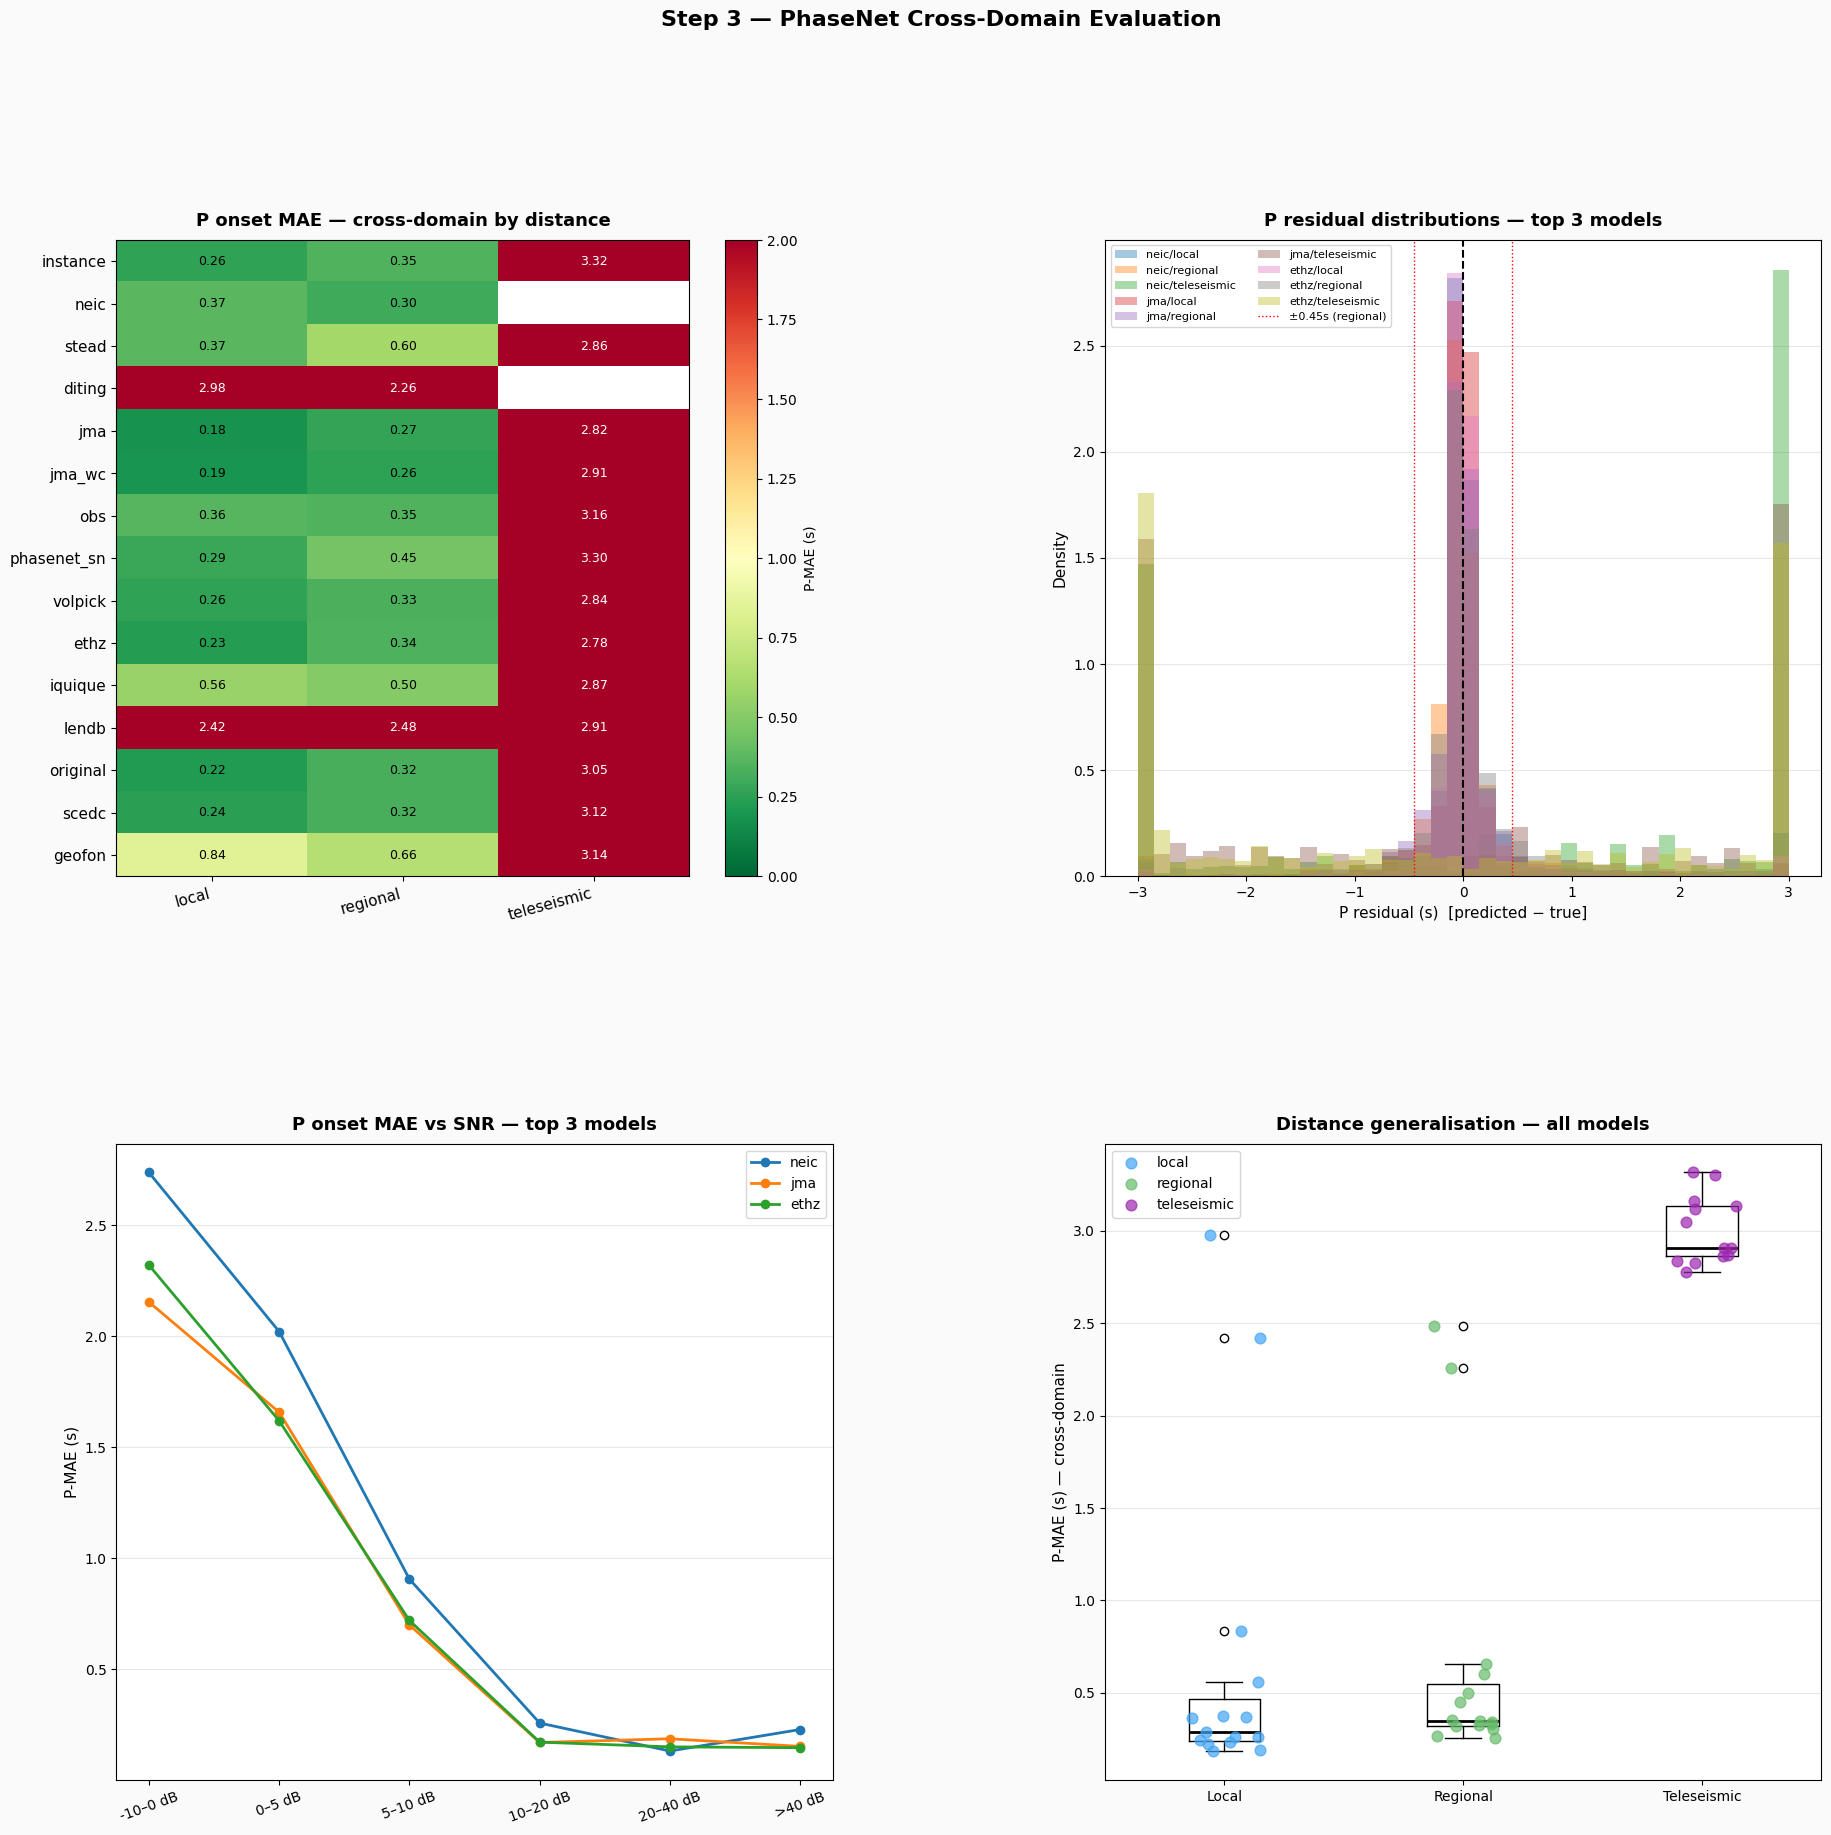

Saved → step3_results.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

metrics_df = pd.read_csv(METRICS_PATH)
results_df = pd.read_parquet(RESULTS_PATH)

TIER_COLORS = {"A":"#2196F3","B":"#FF9800","C":"#4CAF50","D":"#9C27B0"}
DIST_ORDER  = ["local (<150km)","regional (150-1500km)","teleseismic (>1500km)"]

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle("Step 3 — PhaseNet Cross-Domain Evaluation", fontsize=16,
             fontweight="bold", y=0.995)

# ── Panel 1: P-MAE heatmap (models × distance bins) ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cross = metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"].isin(DIST_ORDER))]
pivot = cross.pivot_table(index="weight", columns="dist_bin",
                           values="p_mae_s", aggfunc="first")
pivot = pivot.reindex(columns=DIST_ORDER)

# Sort by tier then mean MAE
pivot["_tier"] = [PHASENET_WEIGHTS.get(w,{}).get("tier","?") for w in pivot.index]
pivot = pivot.sort_values(["_tier","_tier"]).drop(columns=["_tier"])

im = ax1.imshow(pivot.values.astype(float), aspect="auto",
                cmap="RdYlGn_r", vmin=0, vmax=2.0)
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([c.split(" (")[0] for c in pivot.columns],
                     fontsize=11, rotation=15, ha="right")
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels(pivot.index, fontsize=11)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=9, color="white" if val > 1.0 else "black")
plt.colorbar(im, ax=ax1, label="P-MAE (s)")
ax1.set_title("P onset MAE — cross-domain by distance", fontsize=13,
              fontweight="bold", pad=10)

# ── Panel 2: Residual distributions by distance ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top3 = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="all")]
        .nsmallest(3, "p_mae_s")["weight"].tolist())

for weight in top3:
    for dist in DIST_ORDER:
        sub = results_df[(results_df["weight"]==weight) &
                          (results_df["dist_bin"]==dist) &
                          (results_df["p_in_window"]>=0) &
                          (results_df["p_residual_s"].notna())]
        if len(sub) < 5: continue
        res = sub["p_residual_s"].clip(-3, 3)
        ax2.hist(res, bins=40, alpha=0.4, density=True, label=f"{weight}/{dist.split(' ')[0]}")

ax2.axvline(0, color="black", lw=1.5, linestyle="--")
ax2.axvline( OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":", label=f"±{OUTLIER_REGIONAL}s (regional)")
ax2.axvline(-OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":")
ax2.set_xlabel("P residual (s)  [predicted − true]", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("P residual distributions — top 3 models", fontsize=13,
              fontweight="bold", pad=10)
ax2.legend(fontsize=8, ncol=2)
ax2.tick_params(labelsize=10)
ax2.set_facecolor("white"); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

# ── Panel 3: P-MAE vs SNR bins ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
snr_bins = [-10, 0, 5, 10, 20, 40, 100]
snr_labels = ["-10–0","0–5","5–10","10–20","20–40",">40"]

for weight in top3:
    wdf = results_df[(results_df["weight"]==weight) &
                      (results_df["p_in_window"]>=0) &
                      (results_df["p_residual_s"].notna())].copy()
    wdf["snr_bin"] = pd.cut(wdf["snr_db"], bins=snr_bins, labels=snr_labels)
    mae_by_snr = wdf.groupby("snr_bin", observed=True)["p_residual_s"].apply(
        lambda x: np.abs(x).mean())
    ax3.plot(range(len(mae_by_snr)), mae_by_snr.values, marker="o",
             linewidth=2, markersize=6, label=weight)

ax3.set_xticks(range(len(snr_labels)))
ax3.set_xticklabels([f"{l} dB" for l in snr_labels], fontsize=10, rotation=20)
ax3.set_ylabel("P-MAE (s)", fontsize=11)
ax3.set_title("P onset MAE vs SNR — top 3 models", fontsize=13,
              fontweight="bold", pad=10)
ax3.legend(fontsize=10)
ax3.tick_params(labelsize=10)
ax3.set_facecolor("white"); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)

# ── Panel 4: Teleseismic gap — all models ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cross_all = (metrics_df[(metrics_df["split"]=="cross_domain") &
                          (metrics_df["dist_bin"].isin(DIST_ORDER))]
             .pivot_table(index="weight", columns="dist_bin",
                          values="p_mae_s", aggfunc="first")
             .reindex(columns=DIST_ORDER))

x = np.arange(len(cross_all))
for j, dist in enumerate(DIST_ORDER):
    col_vals = cross_all[dist].values.astype(float)
    ax4.scatter(np.full(len(col_vals), j) + np.random.uniform(-0.15, 0.15, len(col_vals)),
                col_vals, s=60, alpha=0.7, zorder=3,
                color=["#42A5F5","#66BB6A","#9C27B0"][j], label=dist.split(" (")[0])

ax4.boxplot([cross_all[d].dropna().values for d in DIST_ORDER],
            positions=[0,1,2], widths=0.3, patch_artist=False,
            medianprops=dict(color="black",lw=2))
ax4.set_xticks([0,1,2])
ax4.set_xticklabels(["Local","Regional","Teleseismic"], fontsize=12)
ax4.set_ylabel("P-MAE (s) — cross-domain", fontsize=11)
ax4.set_title("Distance generalisation — all models", fontsize=13,
              fontweight="bold", pad=10)
ax4.legend(fontsize=10)
ax4.tick_params(labelsize=10)
ax4.set_facecolor("white"); ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)

plt.savefig("step3_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → step3_results.png")


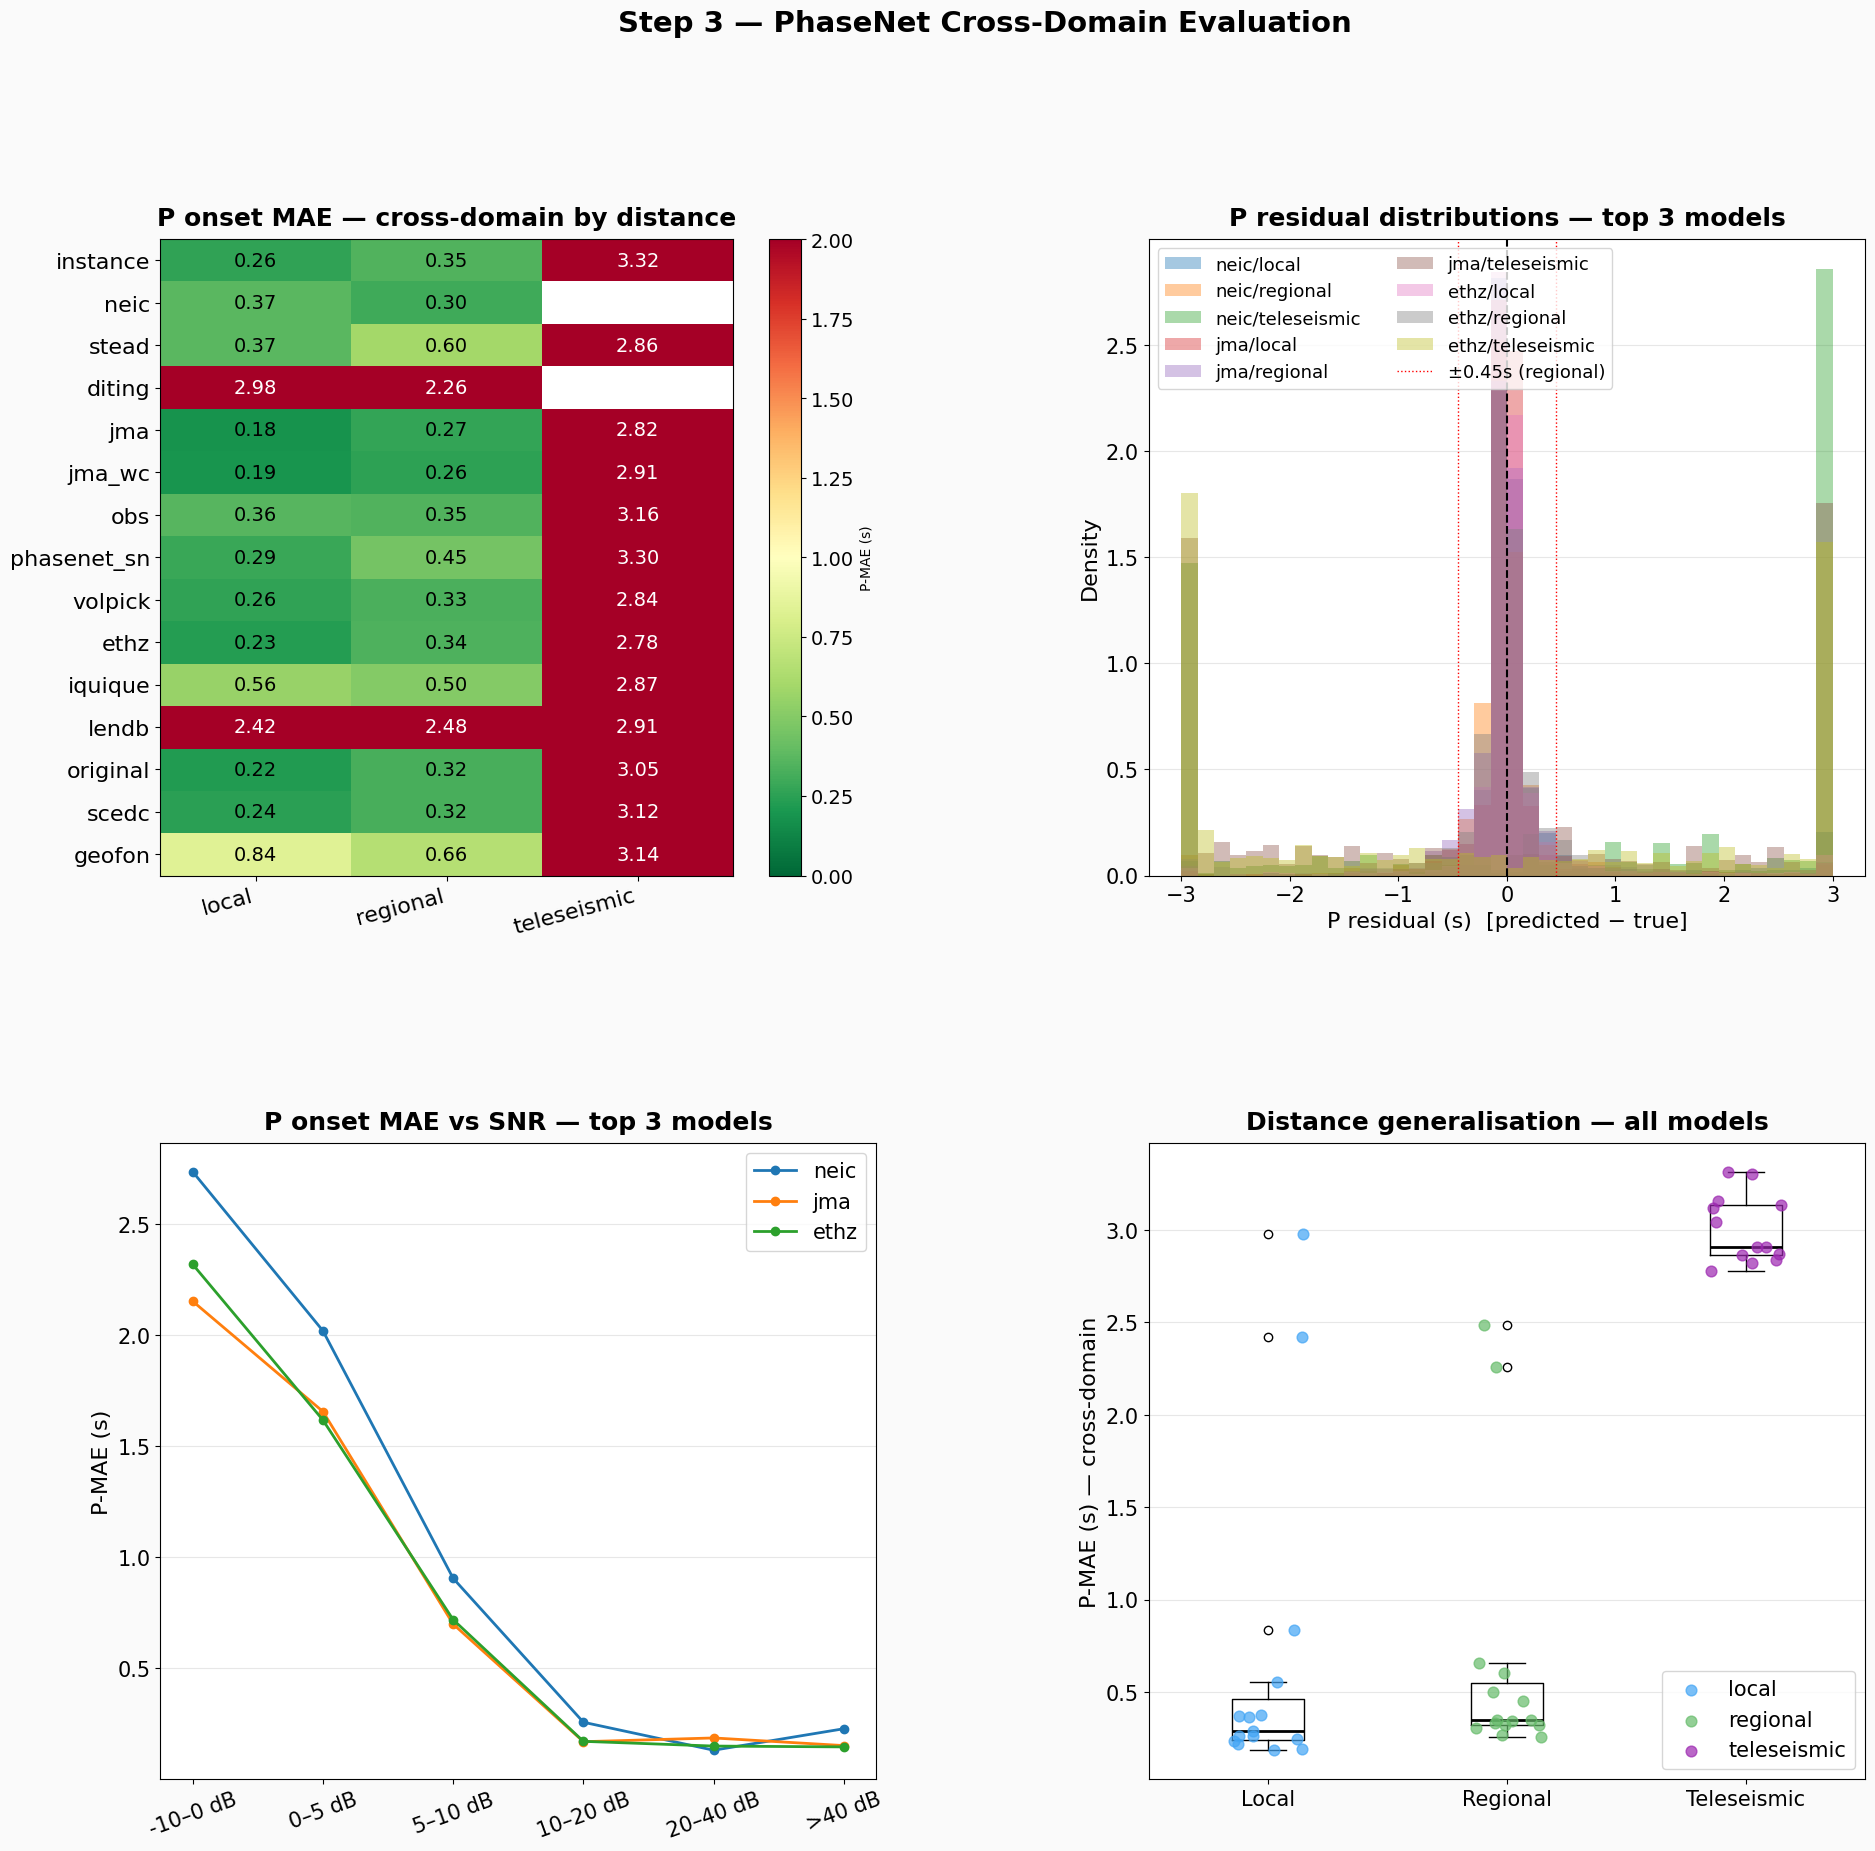

Saved → step3_results.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

metrics_df = pd.read_csv(METRICS_PATH)
results_df = pd.read_parquet(RESULTS_PATH)

TIER_COLORS = {"A":"#2196F3","B":"#FF9800","C":"#4CAF50","D":"#9C27B0"}
DIST_ORDER  = ["local (<150km)","regional (150-1500km)","teleseismic (>1500km)"]

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle("Step 3 — PhaseNet Cross-Domain Evaluation", fontsize=21,  # 16→21
             fontweight="bold", y=0.995)

# ── Panel 1: P-MAE heatmap ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cross = metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"].isin(DIST_ORDER))]
pivot = cross.pivot_table(index="weight", columns="dist_bin",
                           values="p_mae_s", aggfunc="first")
pivot = pivot.reindex(columns=DIST_ORDER)
pivot["_tier"] = [PHASENET_WEIGHTS.get(w,{}).get("tier","?") for w in pivot.index]
pivot = pivot.sort_values(["_tier","_tier"]).drop(columns=["_tier"])

im = ax1.imshow(pivot.values.astype(float), aspect="auto",
                cmap="RdYlGn_r", vmin=0, vmax=2.0)
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([c.split(" (")[0] for c in pivot.columns],
                     fontsize=16, rotation=15, ha="right")  # 11→16
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels(pivot.index, fontsize=16)  # 11→16
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=14, color="white" if val > 1.0 else "black")  # 9→14
plt.colorbar(im, ax=ax1, label="P-MAE (s)").ax.tick_params(labelsize=14)  # added tick size
ax1.set_title("P onset MAE — cross-domain by distance", fontsize=18,  # 13→18
              fontweight="bold", pad=10)

# ── Panel 2: Residual distributions ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top3 = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="all")]
        .nsmallest(3, "p_mae_s")["weight"].tolist())

for weight in top3:
    for dist in DIST_ORDER:
        sub = results_df[(results_df["weight"]==weight) &
                          (results_df["dist_bin"]==dist) &
                          (results_df["p_in_window"]>=0) &
                          (results_df["p_residual_s"].notna())]
        if len(sub) < 5: continue
        res = sub["p_residual_s"].clip(-3, 3)
        ax2.hist(res, bins=40, alpha=0.4, density=True, label=f"{weight}/{dist.split(' ')[0]}")

ax2.axvline(0, color="black", lw=1.5, linestyle="--")
ax2.axvline( OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":", label=f"±{OUTLIER_REGIONAL}s (regional)")
ax2.axvline(-OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":")
ax2.set_xlabel("P residual (s)  [predicted − true]", fontsize=16)  # 11→16
ax2.set_ylabel("Density", fontsize=16)  # 11→16
ax2.set_title("P residual distributions — top 3 models", fontsize=18,  # 13→18
              fontweight="bold", pad=10)
ax2.legend(fontsize=13, ncol=2)  # 8→13
ax2.tick_params(labelsize=15)  # 10→15
ax2.set_facecolor("white"); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

# ── Panel 3: P-MAE vs SNR bins ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
snr_bins = [-10, 0, 5, 10, 20, 40, 100]
snr_labels = ["-10–0","0–5","5–10","10–20","20–40",">40"]

for weight in top3:
    wdf = results_df[(results_df["weight"]==weight) &
                      (results_df["p_in_window"]>=0) &
                      (results_df["p_residual_s"].notna())].copy()
    wdf["snr_bin"] = pd.cut(wdf["snr_db"], bins=snr_bins, labels=snr_labels)
    mae_by_snr = wdf.groupby("snr_bin", observed=True)["p_residual_s"].apply(
        lambda x: np.abs(x).mean())
    ax3.plot(range(len(mae_by_snr)), mae_by_snr.values, marker="o",
             linewidth=2, markersize=6, label=weight)

ax3.set_xticks(range(len(snr_labels)))
ax3.set_xticklabels([f"{l} dB" for l in snr_labels], fontsize=15, rotation=20)  # 10→15
ax3.set_ylabel("P-MAE (s)", fontsize=16)  # 11→16
ax3.set_title("P onset MAE vs SNR — top 3 models", fontsize=18,  # 13→18
              fontweight="bold", pad=10)
ax3.legend(fontsize=15)  # 10→15
ax3.tick_params(labelsize=15)  # 10→15
ax3.set_facecolor("white"); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)

# ── Panel 4: Teleseismic gap ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cross_all = (metrics_df[(metrics_df["split"]=="cross_domain") &
                          (metrics_df["dist_bin"].isin(DIST_ORDER))]
             .pivot_table(index="weight", columns="dist_bin",
                          values="p_mae_s", aggfunc="first")
             .reindex(columns=DIST_ORDER))

x = np.arange(len(cross_all))
for j, dist in enumerate(DIST_ORDER):
    col_vals = cross_all[dist].values.astype(float)
    ax4.scatter(np.full(len(col_vals), j) + np.random.uniform(-0.15, 0.15, len(col_vals)),
                col_vals, s=60, alpha=0.7, zorder=3,
                color=["#42A5F5","#66BB6A","#9C27B0"][j], label=dist.split(" (")[0])

ax4.boxplot([cross_all[d].dropna().values for d in DIST_ORDER],
            positions=[0,1,2], widths=0.3, patch_artist=False,
            medianprops=dict(color="black",lw=2))
ax4.set_xticks([0,1,2])
ax4.set_xticklabels(["Local","Regional","Teleseismic"], fontsize=17)  # 12→17
ax4.set_ylabel("P-MAE (s) — cross-domain", fontsize=16)  # 11→16
ax4.set_title("Distance generalisation — all models", fontsize=18,  # 13→18
              fontweight="bold", pad=10)
ax4.legend(fontsize=15)  # 10→15
ax4.tick_params(labelsize=15)  # 10→15
ax4.set_facecolor("white"); ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)

plt.savefig("step3_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → step3_results.png")

## 3.7  Thesis-Ready Results Table


In [8]:
metrics_df = pd.read_csv(METRICS_PATH)

# ── Full results table: cross-domain, per distance bin ────────────────────
table = (metrics_df[metrics_df["split"] == "cross_domain"]
         .pivot_table(index=["tier","weight"],
                      columns="dist_bin",
                      values=["p_mae_s","p_recall","mcc"],
                      aggfunc="first")
         .round(3))

print("Cross-domain results by distance bin")
print("Columns: p_mae_s (P onset MAE in seconds) | p_recall | mcc (phase ID)")
print("=" * 100)
print(table.to_string())

# ── Key finding: teleseismic gap ──────────────────────────────────────────
tele = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="teleseismic (>1500km)")]
        .sort_values("p_mae_s")[["weight","tier","n_traces","p_recall","p_mae_s","mcc"]])

print("\n\nTeleseismic cross-domain performance (sorted by P-MAE):")
print(tele.to_string(index=False))

# Save formatted table for thesis
table.to_csv("step3_thesis_table.csv")
tele.to_csv("step3_teleseismic_table.csv", index=False)
print("\nSaved step3_thesis_table.csv and step3_teleseismic_table.csv")


Cross-domain results by distance bin
Columns: p_mae_s (P onset MAE in seconds) | p_recall | mcc (phase ID)
                    mcc                                      p_mae_s                                                            p_recall                                                           
dist_bin            all local (<150km) regional (150-1500km)     all local (<150km) regional (150-1500km) teleseismic (>1500km)      all local (<150km) regional (150-1500km) teleseismic (>1500km)
tier weight                                                                                                                                                                                        
A    instance     0.742          0.708                 0.828   1.665          0.259                 0.348                 3.315    0.470          0.854                 0.866                 0.000
     neic         0.215          0.265                 0.075   0.338          0.369                 0.304    